[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/YOUR_REPO/blob/main/Alternative_Role_Classifier_Analyzer.ipynb)

**📝 Before using:** Update the GitHub URL above with your actual username and repository name.

## 2. File Upload and Data Loading

In [3]:
# =========================================================================
# ☢ STEP 1: CHOOSE YOUR MODEL MODE
# =========================================================================

# Select one of the following modes:
#
# API-based (Requires API Keys):
#   1. 'CLAUDE_API'            - Anthropic Claude Sonnet 4 / 4.5
#   2. 'GEMINI_API'            - Google Gemini 2.0 / 2.5
#   3. 'MISTRAL_API'           - Mistral Large / Small / NeMo
#   4. 'HUGGINGFACE_API'       - Serverless Inference (Falcon, Qwen)
#
# Local/HuggingFace (Requires Colab GPU):
#   5. 'LLAMA_8B'              - Meta Llama 3.1 8B Instruct
#   6. 'LLAMA_70B'             - Meta Llama 3.1 70B Instruct (A100 recommended)

MODEL_MODE = 'LLAMA_70B'  # <<< Set to MISTRAL_API to use it >>>

# =========================================================================
# ☥ STEP 2: API Keys & General Configuration
# =========================================================================

import os
import json
import zipfile
import pandas as pd
from tqdm.auto import tqdm
from google.colab import files, userdata

# API Keys (Set via Colab Secrets ☥ or manually here)
ANTHROPIC_API_KEY = ""
GEMINI_API_KEY = ""
MISTRAL_API_KEY = "" # <<< ADD MISTRAL API KEY HERE >>>
HF_TOKEN = userdata.get('LLamaCoLab') # Retrieve the user's Hugging Face token from secrets

# General Settings
ZIP_FILE_PATH = "/content/Evaluation Resources.zip"
OUTPUT_PATH = "/content/analysis_results"
MAX_TOKENS = 4096
TEMPERATURE = 0.1

# -------------------------------------------------------------------------
# MISTRAL CONFIGURATION
# -------------------------------------------------------------------------
MISTRAL_MODEL_NAME = "mistral-large-latest" # or "mistral-small-latest", "open-mistral-nemo"

# -------------------------------------------------------------------------
# HUGGING FACE API CONFIGURATION
# -------------------------------------------------------------------------
#HF_MODEL_ID = "tiiuae/falcon-180B-chat"
HF_MODEL_ID = "Qwen/Qwen2.5-72B-Instruct"

# OTHER CONFIGS (Do not change)
CLAUDE_MODEL_NAME = "claude-sonnet-4-20250514"
#CLAUDE_MODEL_NAME = "claude-sonnet-4-20250514"
# CLAUDE_MODEL_NAME = "claude-opus-4-1-20250805" # Claude Opus 4.1
#CLAUDE_FALLBACK_MODEL = "claude-sonnet-4-5-20250929"  # Fallback to Sonnet 4.5 if needed
GEMINI_MODEL_NAME = "gemini-2.5-pro"
#LLAMA_8B_MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"
LLAMA_70B_MODEL_NAME = "meta-llama/Llama-3.1-70B-Instruct"
USE_4BIT_QUANTIZATION = True

# =========================================================================
# ⟳ STEP 3: Dependency Installation
# =========================================================================

# Build install command
install_command = "pip install -q pandas numpy matplotlib seaborn plotly networkx tqdm sentence-transformers"

if MODEL_MODE == 'CLAUDE_API':
    install_command += " anthropic>=0.34.0"
    try: ANTHROPIC_API_KEY = userdata.get('ANTHROPIC_API_KEY')
    except: pass
elif MODEL_MODE == 'GEMINI_API':
    install_command += " google-genai"
    try: GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    except: pass
elif MODEL_MODE == 'MISTRAL_API':
    install_command += " mistralai"
    try: MISTRAL_API_KEY = userdata.get('MISTRAL_API_KEY')
    except: pass
elif MODEL_MODE == 'HUGGINGFACE_API':
    install_command += " huggingface_hub"
    # HF_TOKEN is already set from userdata.get('LLamaCoLab') above.
    # No need to try/except for specific names here if LLamaCoLab is the source.
    # If other HF keys are preferred for this mode, add fallback logic.
    pass
else:
    install_command += " torch torchvision torchaudio transformers accelerate bitsandbytes"

print(f"\n📦 Installing dependencies for {MODEL_MODE}...")
os.system(install_command)
print("✅ Dependencies installed.\n")


📦 Installing dependencies for LLAMA_70B...
✅ Dependencies installed.



In [4]:
print("⬆️ Please upload 'Evaluation Resources.zip' when prompted.\n")
uploaded = files.upload()

if 'Evaluation Resources.zip' not in uploaded:
    raise FileNotFoundError("❌ 'Evaluation Resources.zip' not found. Please upload the file.")

# Extract zip file
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall("/content/")
print("✅ Files extracted successfully.\n")

# =========================================================================
# ƒ LOAD DATA FILES
# =========================================================================

from typing import List, Dict

def find_and_load_json(filename: str) -> List[Dict]:
    """Search for and load a JSON file from extracted contents."""
    # Prioritize direct path, as zip extraction goes to /content/
    direct_filepath = os.path.join("/content/", filename)
    if os.path.exists(direct_filepath):
        with open(direct_filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        print(f"  ✅ Loaded {filename}: {len(data)} records")
        return data

    # Fallback to os.walk if not found directly (e.g., if extracted to a subdirectory)
    for root, dirs, files_list in os.walk("/content/"):
        for file in files_list:
            if file.lower() == filename.lower():
                filepath = os.path.join(root, file)
                with open(filepath, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                print(f"  ✅ Loaded {filename}: {len(data)} records")
                return data
    print(f"  ❌ Warning: {filename} not found")
    return []

print("🔍 Loading data files...\n")

# Load all required files
sample_jds = find_and_load_json('Sample_JDs.json')
classifications = find_and_load_json('Job_Classifications_Batch.json')
ground_truth = find_and_load_json('Ground_Truth_Masterfile.json')
ksacs = find_and_load_json('MNPS_KSACs.json')
problem_roles = find_and_load_json('Problem_Role_Cheat_Sheet.json') # Corrected filename

# Store in dictionary for easy access
datasets = {
    'sample_jds': sample_jds,
    'classifications': classifications,
    'ground_truth': ground_truth,
    'ksacs': ksacs,
    'problem_roles': problem_roles
}

print(f"\n✅ Data loading complete!")

⬆️ Please upload 'Evaluation Resources.zip' when prompted.



Saving Evaluation Resources.zip to Evaluation Resources.zip
✅ Files extracted successfully.

🔍 Loading data files...

  ✅ Loaded Sample_JDs.json: 22 records
  ✅ Loaded Job_Classifications_Batch.json: 22 records
  ✅ Loaded Ground_Truth_Masterfile.json: 176 records
  ✅ Loaded MNPS_KSACs.json: 315 records
  ✅ Loaded Problem_Role_Cheat_Sheet.json: 8 records

✅ Data loading complete!


## 3. Data Preparation

In [5]:
# =========================================================================
# 🔗 MERGE JOB DESCRIPTIONS WITH CLASSIFICATIONS
# =========================================================================

def prepare_analysis_data(datasets: Dict) -> pd.DataFrame:
    """Merge job descriptions with classifications for analysis."""

    # Convert to DataFrames
    df_jds = pd.DataFrame(datasets['sample_jds'])
    df_class = pd.DataFrame(datasets['classifications'])

    # Standardize job titles for merging
    df_jds['Job Title'] = df_jds['Job Title'].astype(str).str.strip()
    df_class['job_title_original'] = df_class['job_title_original'].astype(str).str.strip()

    # Merge on job title (1:1 relationship)
    df_merged = pd.merge(
        df_class,
        df_jds,
        left_on='job_title_original',
        right_on='Job Title',
        how='inner'
    )

    # Create full job description text
    def create_jd_text(row):
        parts = []
        if 'Position Summary' in row and pd.notna(row['Position Summary']):
            parts.append(f"Position Summary: {row['Position Summary']}")
        if 'Essential Functions' in row and pd.notna(row['Essential Functions']):
            parts.append(f"Essential Functions: {row['Essential Functions']}")
        if 'Education' in row and pd.notna(row['Education']):
            parts.append(f"Education: {row['Education']}")
        if 'Work Experience' in row and pd.notna(row['Work Experience']):
            parts.append(f"Work Experience: {row['Work Experience']}")
        if 'Knowledge, Skills and Abilities' in row and pd.notna(row['Knowledge, Skills and Abilities']):
            parts.append(f"Knowledge, Skills and Abilities: {row['Knowledge, Skills and Abilities']}")
        return "\n\n".join(parts)

    df_merged['full_job_description'] = df_merged.apply(create_jd_text, axis=1)

    print(f"✅ Prepared {len(df_merged)} job records for analysis")

    if len(df_merged) != len(df_class):
        print(f"⚠️ Warning: {len(df_class) - len(df_merged)} records did not merge")

    return df_merged

# Prepare the analysis dataset
df_analysis = prepare_analysis_data(datasets)

# Display sample
print("\n📋 Sample records:")
display(df_analysis[['Job Code', 'job_title_original', 'major_role_group']].head())

✅ Prepared 22 job records for analysis

📋 Sample records:


,Job Code,job_title_original,major_role_group
0,87894,Teacher Grade 8,Teacher
1,86690,Mgr Data Quality and Integrity,Manager
2,85253,Coord Evaluation RAE,Analyst
3,84250,Dir Assessment RAE,Director
4,83552,Analyst Data Operations RAE,Analyst


## 4. Model Initialization

In [6]:
# =========================================================================
# 🤖 MODEL INITIALIZATION (Dynamic Switcher)
# =========================================================================
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Reset variables
model_client = None
model_tokenizer = None
embedding_model = None
reference_context = ""

print(f"🔄 Initializing for mode: {MODEL_MODE}...")

# -------------------------------------------------------------------------
# OPTION A: ANTHROPIC CLAUDE
# -------------------------------------------------------------------------
if MODEL_MODE == 'CLAUDE_API':
    import anthropic
    if not ANTHROPIC_API_KEY: raise ValueError("❌ Missing ANTHROPIC_API_KEY.")
    client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
    model_name = CLAUDE_MODEL_NAME
    model_client = client
    print(f"✅ Claude client initialized: {model_name}")

# -------------------------------------------------------------------------
# OPTION B: GOOGLE GEMINI
# -------------------------------------------------------------------------
elif MODEL_MODE == 'GEMINI_API':
    import google.generativeai as genai
    if not GEMINI_API_KEY: raise ValueError("❌ Missing GEMINI_API_KEY.")
    genai.configure(api_key=GEMINI_API_KEY)
    model = genai.GenerativeModel(GEMINI_MODEL_NAME)
    model_name = GEMINI_MODEL_NAME
    model_client = model
    print(f"✅ Gemini client initialized: {model_name}")

# -------------------------------------------------------------------------
# OPTION C: MISTRAL API (Official)
# -------------------------------------------------------------------------
elif MODEL_MODE == 'MISTRAL_API':
    from mistralai import Mistral
    if not MISTRAL_API_KEY: raise ValueError("❌ Missing MISTRAL_API_KEY.")

    client = Mistral(api_key=MISTRAL_API_KEY)
    model_name = MISTRAL_MODEL_NAME
    model_client = client
    print(f"✅ Mistral client initialized: {model_name}")

# -------------------------------------------------------------------------
# OPTION D: HUGGING FACE API
# -------------------------------------------------------------------------
elif MODEL_MODE == 'HUGGINGFACE_API':
    from huggingface_hub import InferenceClient
    if not HF_TOKEN: print("⚠️ WARNING: No HF_TOKEN found.")
    client = InferenceClient(token=HF_TOKEN)
    model_name = HF_MODEL_ID
    model_client = client
    print(f"✅ Hugging Face API client initialized: {model_name}")

# -------------------------------------------------------------------------
# OPTION E: LOCAL MODELS
# -------------------------------------------------------------------------
elif MODEL_MODE in ['LLAMA_8B', 'LLAMA_70B']:
    if MODEL_MODE == 'LLAMA_8B': local_model_id = LLAMA_8B_MODEL_NAME
    else: local_model_id = LLAMA_70B_MODEL_NAME

    print(f"📥 Loading Local Model: {local_model_id}...")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16
    )
    model_tokenizer = AutoTokenizer.from_pretrained(local_model_id, token=HF_TOKEN)
    model_tokenizer.pad_token = model_tokenizer.eos_token
    model_client = AutoModelForCausalLM.from_pretrained(
        local_model_id, quantization_config=bnb_config, device_map="auto", token=HF_TOKEN
    )
    model_name = local_model_id
    print(f"✅ Local model loaded: {local_model_id}")

else:
    raise ValueError(f"❌ Invalid MODEL_MODE: {MODEL_MODE}")

# Initialize Embedding Model (Common)
try:
    print("\n📥 Loading Embedding Model: BAAI/bge-m3...")
    from sentence_transformers import SentenceTransformer
    embedding_model = SentenceTransformer('BAAI/bge-m3')
    print("✅ Embedding model loaded: BAAI/bge-m3")
except Exception as e:
    print(f"⚠️ Could not load embedding model: {e}")

🔄 Initializing for mode: LLAMA_70B...
📥 Loading Local Model: meta-llama/Llama-3.1-70B-Instruct...


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

model-00029-of-00030.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00030-of-00030.safetensors:   0%|          | 0.00/2.10G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/30 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/183 [00:00<?, ?B/s]

✅ Local model loaded: meta-llama/Llama-3.1-70B-Instruct

📥 Loading Embedding Model: BAAI/bge-m3...
✅ Embedding model loaded: BAAI/bge-m3


In [ ]:
# =========================================================================
# 🔢 OPTIONAL: BAAI BGE-M3 EMBEDDING MODEL
# =========================================================================
# This cell provides embedding functionality using BAAI/bge-m3
# Useful for semantic similarity analysis of job descriptions

def initialize_embedding_model():
    """Initialize the BAAI bge-m3 embedding model via HuggingFace API"""
    from huggingface_hub import InferenceClient

    try:
        hf_token = userdata.get('HF_TOKEN') if 'HF_TOKEN' not in globals() or not HF_TOKEN else HF_TOKEN
    except:
        hf_token = HF_TOKEN if HF_TOKEN else None

    if not hf_token:
        print("⚠️ HuggingFace API token not found. Please set HF_TOKEN in Colab secrets.")
        return None

    embedding_client = InferenceClient(token=hf_token)
    print("✅ BGE-M3 embedding model initialized")
    return embedding_client

def get_embeddings(texts: List[str], embedding_client) -> List[List[float]]:
    """Get embeddings for a list of texts using BAAI/bge-m3"""
    embeddings = []

    for text in tqdm(texts, desc="Generating embeddings"):
        try:
            # Get embedding from HuggingFace API
            embedding = embedding_client.feature_extraction(
                text=text,
                model="BAAI/bge-m3"
            )
            embeddings.append(embedding)
        except Exception as e:
            print(f"Error getting embedding: {e}")
            embeddings.append(None)

    return embeddings

def compute_similarity(embedding1: List[float], embedding2: List[float]) -> float:
    """Compute cosine similarity between two embeddings"""
    import numpy as np

    if embedding1 is None or embedding2 is None:
        return 0.0

    # Convert to numpy arrays
    vec1 = np.array(embedding1)
    vec2 = np.array(embedding2)

    # Compute cosine similarity
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot_product / (norm1 * norm2)

# Uncomment below to initialize embedding model
# embedding_client = initialize_embedding_model()

print("\n📊 Embedding functions defined. Use initialize_embedding_model() to activate.")
print("   Then use get_embeddings() and compute_similarity() for semantic analysis.\n")

## 5. Alternative Role Analyzer

In [7]:
# =========================================================================
# 🔎 ALTERNATIVE ROLE ANALYZER (Universal)
# =========================================================================

import time
import json
import pandas as pd
from tqdm.auto import tqdm
from typing import Dict, List, Optional

MAX_RETRIES = 3
RETRY_DELAY = 2
MAX_TOKENS = 2000
TEMPERATURE = 0.0

class AlternativeRoleAnalyzer:
    def __init__(self, df, datasets, model_mode, client, model_name_str, tokenizer=None, reference_ctx=None):
        self.df = df
        self.datasets = datasets
        self.model_mode = model_mode
        self.client = client
        self.model_name = model_name_str
        self.tokenizer = tokenizer
        self.reference_context = reference_ctx or ""

        # Load Valid Roles
        self.valid_roles_list = []
        if self.datasets and 'ksacs' in self.datasets:
            self.valid_roles_list = sorted(list(set(
                str(record.get('Role', '')).strip()
                for record in self.datasets['ksacs']
                if record.get('Role')
            )))
        self.valid_roles_str = ", ".join(f"'{r}'" for r in self.valid_roles_list)
        print(f"ℹ️ Configured with {len(self.valid_roles_list)} valid roles.")

    def create_analysis_prompt(self, row: pd.Series) -> str:
        job_code = row.get('Job Code', 'N/A')
        job_title = row.get('job_title_original', 'N/A')
        classified_role = row.get('major_role_group', 'N/A')
        job_description = row.get('full_job_description', 'N/A')

        ground_truth = 'N/A'
        if self.datasets and 'ground_truth' in self.datasets:
            for gt_record in self.datasets['ground_truth']:
                if gt_record.get('Job Title', '').strip() == job_title.strip():
                    ground_truth = gt_record.get('major_role_group', 'N/A')
                    break

        return f"""# ALTERNATIVE ROLE IDENTIFICATION TASK
You are an HR classification expert. Identify other plausible major_role_group classifications.

## STRICT CONSTRAINT: VALID ROLES ONLY
You must ONLY select alternative roles from this list:
[{self.valid_roles_str}]

## JOB INFORMATION
**Job Code:** {job_code}
**Job Title:** {job_title}
**Classified Role:** {classified_role}
**Ground Truth:** {ground_truth}

**Job Description:**
{job_description}

## OUTPUT FORMAT
Return ONLY valid JSON:
```json
{{
  "job_code": "{job_code}",
  "classified_role": "{classified_role}",
  "other_plausible_roles": ["Role1", "Role2"],
  "reasoning": "Explanation here."
}}
"""
    def generate_response(self, prompt: str) -> Dict:
        for attempt in range(MAX_RETRIES):
            try:
                response_text = ""

                # --- CLAUDE ---
                if self.model_mode == 'CLAUDE_API':
                    response = self.client.messages.create(
                        model=self.model_name, max_tokens=MAX_TOKENS, temperature=TEMPERATURE,
                        messages=[{"role": "user", "content": prompt}]
                    )
                    response_text = response.content[0].text

                # --- GEMINI ---
                elif self.model_mode == 'GEMINI_API':
                    from google.generativeai import types
                    generation_config = types.GenerationConfig(
                        temperature=TEMPERATURE, max_output_tokens=MAX_TOKENS, response_mime_type="application/json"
                    )
                    response = self.client.generate_content(prompt, generation_config=generation_config)
                    response_text = response.text

                # --- MISTRAL API (Official) ---
                elif self.model_mode == 'MISTRAL_API':
                    response = self.client.chat.complete(
                        model=self.model_name,
                        messages=[{"role": "user", "content": prompt}],
                        temperature=TEMPERATURE,
                        max_tokens=MAX_TOKENS,
                        response_format={"type": "json_object"}
                    )
                    response_text = response.choices[0].message.content

                # --- HUGGING FACE API ---
                elif self.model_mode == 'HUGGINGFACE_API':
                    messages = [{"role": "system", "content": "Output strictly in JSON."}, {"role": "user", "content": prompt}]
                    response = self.client.chat_completion(
                        messages=messages, model=self.model_name, max_tokens=MAX_TOKENS, temperature=TEMPERATURE
                    )
                    response_text = response.choices[0].message.content

                # --- LOCAL MODELS ---
                elif self.model_mode in ['LLAMA_8B', 'LLAMA_70B']:
                    import torch
                    messages = [{"role": "system", "content": "Output valid JSON only."}, {"role": "user", "content": prompt}]
                    formatted_prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
                    inputs = self.tokenizer(formatted_prompt, return_tensors="pt", truncation=True, max_length=4096).to(self.client.device)
                    with torch.no_grad():
                        outputs = self.client.generate(**inputs, max_new_tokens=MAX_TOKENS, temperature=TEMPERATURE, do_sample=False)
                    response_text = self.tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

                # --- CLEANUP ---
                response_text = response_text.strip()
                if response_text.startswith('```json'): response_text = response_text[7:]
                if response_text.startswith('```'): response_text = response_text[3:]
                if response_text.endswith('```'): response_text = response_text[:-3]

                result = json.loads(response_text.strip())
                result['status'] = 'success'
                if 'other_plausible_roles' in result:
                    result['other_plausible_roles'] = [r for r in result['other_plausible_roles'] if r in self.valid_roles_list]
                return result

            except Exception as e:
                if attempt < MAX_RETRIES - 1: time.sleep(RETRY_DELAY * (2 ** attempt))
                else: return {'status': 'failed', 'reasoning': str(e)}

    def analyze_all(self) -> pd.DataFrame:
        results = []
        print(f"\n🚀 Starting analysis with {self.model_mode}...")
        for idx, row in tqdm(self.df.iterrows(), total=len(self.df), desc="Analyzing jobs"):
            prompt = self.create_analysis_prompt(row)
            result = self.generate_response(prompt)
            results.append({
                'Job Code': row.get('Job Code', 'N/A'),
                'Classified Role': row.get('major_role_group', 'N/A'),
                'Other Plausible Roles': ', '.join(result.get('other_plausible_roles', [])),
                'Analysis Reasoning': result.get('reasoning', 'N/A'),
                'Status': result.get('status', 'failed')
            })
        return pd.DataFrame(results)

In [8]:
# =========================================================================
# Initialize Analyzer (if data is loaded)
# =========================================================================

if 'df_analysis' in globals() and 'datasets' in globals():
    analyzer = AlternativeRoleAnalyzer(
        df=df_analysis,
        datasets=datasets,
        model_mode=MODEL_MODE,
        client=model_client, # Now correctly points to the globally defined client
        model_name_str=model_name,
        tokenizer=model_tokenizer, # Now correctly points to the globally defined tokenizer or None
        reference_ctx=reference_context # Now correctly points to the globally defined reference_context
    )
    print("✅ AlternativeRoleAnalyzer initialized and ready!")
    print(f"📊 Loaded {len(df_analysis)} records for analysis")
else:
    print("📦 AlternativeRoleAnalyzer class defined successfully!")
    print("⚠️  Waiting for data to be loaded...")
    print("   Run your data loading step to define 'df_analysis' and 'datasets'")

ℹ️ Configured with 63 valid roles.
✅ AlternativeRoleAnalyzer initialized and ready!
📊 Loaded 22 records for analysis


## 6. Run Analysis

In [9]:
# =========================================================================
# ▶️ EXECUTE ANALYSIS
# =========================================================================

df_results = analyzer.analyze_all()

# Calculate statistics
success_rate = (df_results['Status'] == 'success').mean()
jobs_with_alternatives = (df_results['Other Plausible Roles'].str.len() > 0).sum()
total_jobs = len(df_results)

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE")
print("="*70)
print(f"Total Jobs Analyzed: {total_jobs}")
print(f"Successful Analyses: {(df_results['Status'] == 'success').sum()} ({success_rate:.1%})")
print(f"Jobs with Alternatives: {jobs_with_alternatives} ({jobs_with_alternatives/total_jobs:.1%})")
print("="*70 + "\n")

# Display results
print("📋 Sample Results:\n")
display(df_results.drop(columns=['Status']).head(10))


🚀 Starting analysis with LLAMA_70B...


Analyzing jobs:   0%|          | 0/22 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for op


✅ ANALYSIS COMPLETE
Total Jobs Analyzed: 22
Successful Analyses: 22 (100.0%)
Jobs with Alternatives: 22 (100.0%)

📋 Sample Results:



,Job Code,Classified Role,Other Plausible Roles,Analysis Reasoning
0,87894,Teacher,"Instructor, Trainer, Tutor",The job description highlights the role's focu...
1,86690,Manager,"Director, Supervisor, Specialist",The job description highlights the role's resp...
2,85253,Analyst,Coordinator,The job description highlights the employee's ...
3,84250,Director,"Manager, Supervisor, Executive Officer",The Director of Assessment oversees district-w...
4,83552,Analyst,"Assistant, Associate, Coordinator, Specialist",The job description highlights the importance ...
5,85491,Coordinator,"Advisor, Specialist, Facilitator",The job description highlights the role's expe...
6,88129,Teacher,"Instructor, Trainer, Tutor",The job description highlights the role's focu...
7,85789,Coach,"Counselor, Specialist, Therapist",The job description highlights the need for a ...
8,82509,Coach,"Instructor, Trainer, Developer, Specialist",The job description highlights the role's focu...
9,83222,Coordinator,"Advisor, Counselor, Liaison",The job description highlights the role's resp...


## 7. Visualizations

📊 Generating visualizations...



/tmp/ipython-input-3070838444.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_results, x='alt_count', palette='viridis')


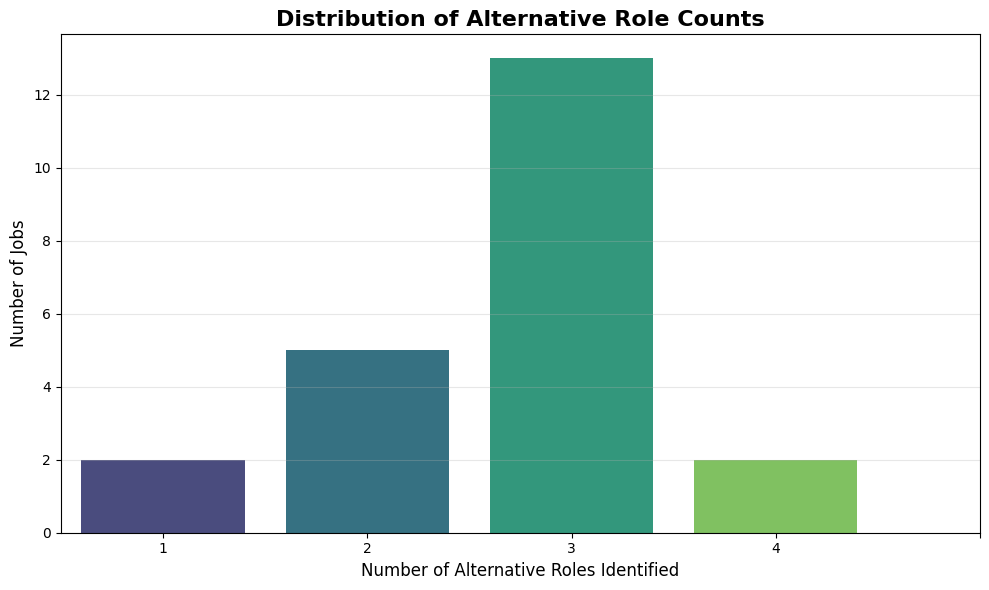

  ✅ Alternative distribution chart saved


/tmp/ipython-input-3070838444.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_roles.values, y=top_roles.index, palette='rocket')


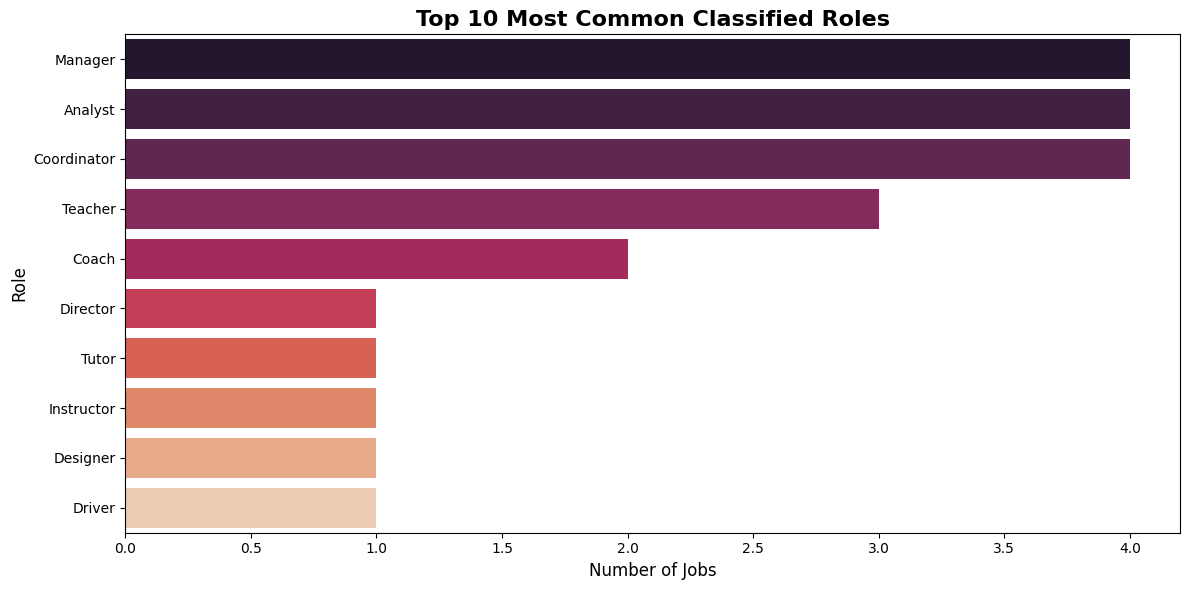

  ✅ Top roles chart saved


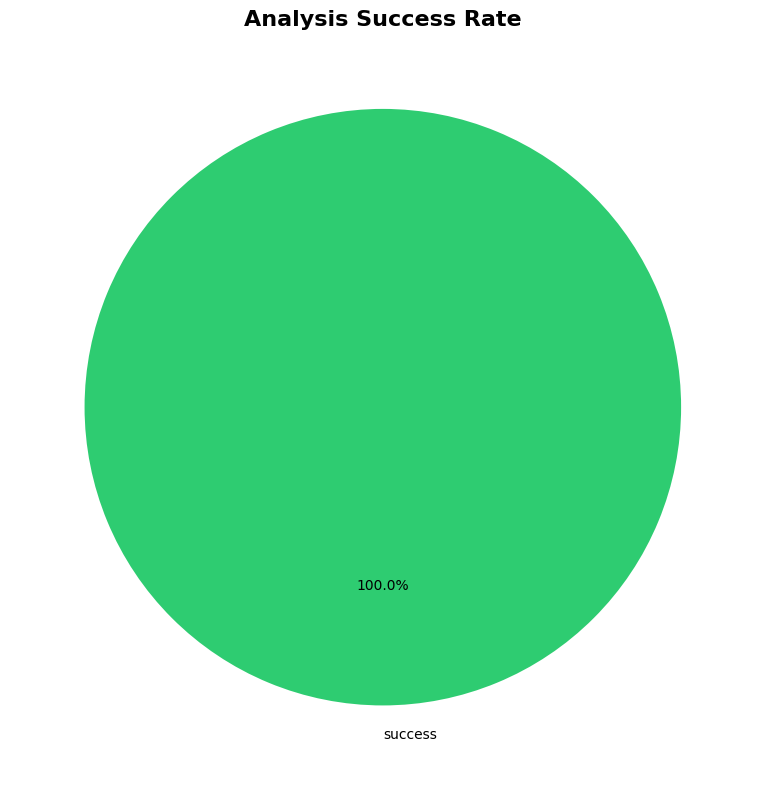

  ✅ Status breakdown chart saved



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("📊 Generating visualizations...\n")

# =========================================================================
# 1. Distribution of Alternative Counts
# =========================================================================

df_results['alt_count'] = df_results['Other Plausible Roles'].apply(
    lambda x: len([r.strip() for r in str(x).split(',') if r.strip()])
)

plt.figure(figsize=(10, 6))
sns.countplot(data=df_results, x='alt_count', palette='viridis')
plt.title('Distribution of Alternative Role Counts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Alternative Roles Identified', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.xticks(range(0, df_results['alt_count'].max() + 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/alternative_distribution.png", dpi=300)
plt.show()

print("  ✅ Alternative distribution chart saved")

# =========================================================================
# 2. Top Classified Roles
# =========================================================================

plt.figure(figsize=(12, 6))
top_roles = df_results['Classified Role'].value_counts().head(10)
sns.barplot(x=top_roles.values, y=top_roles.index, palette='rocket')
plt.title('Top 10 Most Common Classified Roles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('Role', fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/top_roles.png", dpi=300)
plt.show()

print("  ✅ Top roles chart saved")

# =========================================================================
# 3. Analysis Status
# =========================================================================

plt.figure(figsize=(8, 8))
status_counts = df_results['Status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
        colors=colors[:len(status_counts)], startangle=90)
plt.title('Analysis Success Rate', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PATH}/status_breakdown.png", dpi=300)
plt.show()

print("  ✅ Status breakdown chart saved\n")

## 8. Export Results

In [11]:
import shutil

# =========================================================================
# 💾 EXPORT RESULTS
# =========================================================================

# Save main results CSV
output_csv = f"{OUTPUT_PATH}/alternative_roles_analysis_{MODEL_MODE.lower()}.csv"
df_results.drop(columns=['Status', 'alt_count']).to_csv(output_csv, index=False)
print(f"✅ Results saved to: {output_csv}\n")

# Save summary statistics
summary = {
    'model_used': MODEL_MODE,
    'model_name': model_name,
    'total_jobs': total_jobs,
    'successful_analyses': int((df_results['Status'] == 'success').sum()),
    'success_rate': f"{success_rate:.1%}",
    'jobs_with_alternatives': int(jobs_with_alternatives),
    'percentage_with_alternatives': f"{jobs_with_alternatives/total_jobs:.1%}",
    'avg_alternatives_per_job': float(df_results['alt_count'].mean())
}

with open(f"{OUTPUT_PATH}/analysis_summary.json", 'w') as f:
    json.dump(summary, f, indent=2)

print("📊 Analysis Summary:")
print(json.dumps(summary, indent=2))
print()

# Create downloadable zip
print("📦 Creating download package...")
shutil.make_archive('/content/analysis_results', 'zip', OUTPUT_PATH)

try:
    files.download('/content/analysis_results.zip')
    print("✅ Download initiated!\n")
except:
    print(f"⚠️ Could not auto-download. Files saved to: {OUTPUT_PATH}\n")

print("="*70)
print("🎉 ANALYSIS PIPELINE COMPLETE!")
print("="*70)

✅ Results saved to: /content/analysis_results/alternative_roles_analysis_llama_70b.csv

📊 Analysis Summary:
{
  "model_used": "LLAMA_70B",
  "model_name": "meta-llama/Llama-3.1-70B-Instruct",
  "total_jobs": 22,
  "successful_analyses": 22,
  "success_rate": "100.0%",
  "jobs_with_alternatives": 22,
  "percentage_with_alternatives": "100.0%",
  "avg_alternatives_per_job": 2.6818181818181817
}

📦 Creating download package...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download initiated!

🎉 ANALYSIS PIPELINE COMPLETE!


## 9. Model Selection Guide

### Quick Reference

| Model | Type | Speed | Cost | Memory | Best For |
|:------|:-----|:------|:-----|:-------|:---------|
| **Claude Sonnet 4** | API | ⚡⚡⚡ | 💰💰 | N/A | Production, accuracy |
| **Gemini 2.0 Flash** | API | ⚡⚡⚡ | 💰 | N/A | Fast, cost-effective |
| **Falcon-180B** | HF API | ⚡⚡ | 💰 | N/A | Powerful general model |
| **Mixtral-8x22B** | HF API | ⚡⚡ | 💰 | N/A | Strong reasoning |
| **Qwen 2.5 72B** | HF API | ⚡⚡ | 💰 | N/A | Excellent for analysis |
| **Llama 3.1 8B** | Local | ⚡⚡ | Free | ~6GB | Quick testing |
| **Llama 3.1 70B** | Local | ⚡ | Free | ~35GB | High accuracy |
| **Qwen 2.5 7B** | Local | ⚡⚡ | Free | ~5GB | Efficient |
| **Qwen 3 80B** | Local | ⚡ | Free | ~40GB | Best local model |
| **DeepSeek-R1 8B** | Local | ⚡⚡ | Free | ~6GB | Reasoning tasks |

### API Models (Recommended)

#### Anthropic Claude
**Setup:**
1. Get API key: https://console.anthropic.com/
2. Add to Colab Secrets (🔑 icon in left sidebar) as `ANTHROPIC_API_KEY`
3. Set `MODEL_MODE = 'CLAUDE_API'` in Cell 1

**Pros:** Excellent accuracy, fast, prompt caching saves costs  
**Cons:** Moderate cost per request

#### Google Gemini
**Setup:**
1. Get API key: https://aistudio.google.com/
2. Add to Colab Secrets as `GEMINI_API_KEY`
3. Set `MODEL_MODE = 'GEMINI_API'` in Cell 1

**Pros:** Very fast, low cost, good accuracy  
**Cons:** Less sophisticated than Claude for complex reasoning

#### HuggingFace API (NEW!)
**Setup:**
1. Get API key: https://huggingface.co/settings/tokens
2. Add to Colab Secrets as `HUGGINGFACE_API_KEY`
3. Set `MODEL_MODE = 'HUGGINGFACE_API'` in Cell 1
4. Choose model in `HUGGINGFACE_MODEL_NAME`:
   - `"tiiuae/falcon-180B"` - Falcon-180B (powerful, general purpose)
   - `"mistralai/Mixtral-8x22B-Instruct-v0.1"` - Mixtral-8x22B (strong reasoning)
   - `"Qwen/Qwen2.5-72B-Instruct"` - Qwen 2.5 72B (excellent for analysis)

**Available HuggingFace Models:**
- **Falcon-180B**: Large, powerful model with strong general capabilities
- **Mixtral-8x22B-Instruct**: Mixture-of-experts architecture, excellent reasoning
- **Qwen 2.5 72B**: Best available Qwen model on HF API (Note: Qwen3-235B not yet available)

**Note on Requested Models:**
- ✅ **Falcon-180B**: Available and configured
- ⚠️ **Qwen3-235B-A22B (Qwen-Max)**: Not publicly available on HuggingFace API. Using Qwen 2.5 72B as alternative
- ✅ **Mixtral-8x22B-Instruct**: Available and configured
- ℹ️ **BAAI bge-m3**: Embedding model (not for chat) - see separate cell for usage

**Pros:** Multiple model options, competitive pricing, no rate limits  
**Cons:** May be slower than Claude/Gemini for some models

### Embedding Model: BAAI BGE-M3
**Purpose:** Generate semantic embeddings for similarity analysis

**Setup:**
1. Same HuggingFace API key as above
2. Run the embedding cell after model initialization
3. Use `initialize_embedding_model()` to activate

**Functions:**
- `get_embeddings(texts)` - Generate embeddings for text list
- `compute_similarity(emb1, emb2)` - Calculate cosine similarity

**Use Cases:**
- Compare job description similarities
- Find semantically related roles
- Cluster similar positions
- Validate classification boundaries

### Local Models

**Setup:**
1. Enable GPU: Runtime → Change runtime type → GPU
2. Choose model size based on available VRAM
3. Set `MODEL_MODE` to desired model in Cell 1

**Pros:** Free, unlimited requests, private  
**Cons:** Slower, requires GPU, memory constraints

### Recommendations

- **For production analysis:** Claude Sonnet 4 (best accuracy, caching reduces cost)
- **For budget-conscious work:** Gemini 2.0 Flash (fast + cheap)
- **For testing HF models:** Mixtral-8x22B or Qwen 2.5 72B (good balance)
- **For maximum power:** Falcon-180B via HF API
- **For free/private work:** Qwen 2.5 7B or Llama 3.1 8B (local)
- **For best free results:** Qwen 3 80B or Llama 3.1 70B (requires A100 GPU)
- **For semantic analysis:** BAAI bge-m3 embeddings (separate from chat models)

### Troubleshooting

**Out of Memory (Local Models):**
- Use smaller model (8B instead of 70B)
- Ensure 4-bit quantization is enabled
- Request A100 GPU runtime

**API Errors:**
- Check API key in Colab Secrets
- Verify account has credits/access
- Check rate limits (HF API has generous limits)
- For HF: Ensure model is available (some require special access)

**Slow Performance:**
- API models: Already optimized
- Local models: Use smaller model or switch to API
- HF API: Try different model (Mixtral often faster than Falcon)

**Model Not Available:**
- Some HF models require authentication or special access
- Check model card on HuggingFace for requirements
- Try alternative model from the same family